In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
import torch.nn as nn
from sklearn.metrics import classification_report
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

# Выбор устройства
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Загрузка модели и токенизатора
model_base = AutoModel.from_pretrained("google-bert/bert-base-uncased")
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")
model_base.eval().to(device)

# Загрузка датасета
dataset = load_dataset("dair-ai/emotion")
test_dataset = dataset["validation"]

# Токенизация всей выборки БАТЧЕМ (быстро)
def tokenize_fn(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

tokenized = test_dataset.map(tokenize_fn, batched=True)
input_ids = torch.tensor(tokenized["input_ids"])
attention_mask = torch.tensor(tokenized["attention_mask"])
labels = torch.tensor(tokenized["label"])

# Подготовка DataLoader
test_data = TensorDataset(input_ids, attention_mask, labels)
test_loader = DataLoader(test_data, batch_size=64)

# Классификатор (не обучаем, просто рандомная голова)
class ZeroShotEmotionClassifier(nn.Module):
    def __init__(self, base_model, hidden_size=768, num_labels=6):
        super().__init__()
        self.base = base_model
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.base(input_ids=input_ids, attention_mask=attention_mask)
            cls_output = outputs.last_hidden_state[:, 0, :]
        return self.classifier(cls_output)

model = ZeroShotEmotionClassifier(model_base).to(device)
model.eval()

# Предсказания
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids_batch, mask_batch, label_batch = [x.to(device) for x in batch]
        logits = model(input_ids_batch, mask_batch)
        preds = torch.argmax(logits, dim=-1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(label_batch.cpu().tolist())

# Отчёт
print(classification_report(all_labels, all_preds, target_names=dataset["train"].features["label"].names))


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

              precision    recall  f1-score   support

     sadness       0.28      1.00      0.43       550
         joy       0.00      0.00      0.00       704
        love       0.00      0.00      0.00       178
       anger       0.00      0.00      0.00       275
        fear       0.00      0.00      0.00       212
    surprise       0.00      0.00      0.00        81

    accuracy                           0.28      2000
   macro avg       0.05      0.17      0.07      2000
weighted avg       0.08      0.28      0.12      2000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
from sklearn.metrics import classification_report
import numpy as np
import time

import os
os.environ["WANDB_DISABLED"] = "true"

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Загрузка модели и токенизатора
model_name = "google-bert/bert-base-uncased"
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6).to(device)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Загрузка и токенизация датасета
dataset = load_dataset("dair-ai/emotion")

def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

encoded_dataset = dataset.map(preprocess_function, batched=True)
encoded_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

# Метрики
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": (preds == labels).mean()
    }

# Аргументы обучения
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    logging_dir="./logs"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    compute_metrics=compute_metrics,
)

# 📏 Засекаем время и ресурсы
torch.cuda.reset_peak_memory_stats()
start_time = time.time()

trainer.train()

train_time = time.time() - start_time
gpu_memory = torch.cuda.max_memory_allocated(device=device) / 1e6  # MB

# 🧠 Количество обучаемых параметров
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# 📊 Оценка на тесте
preds_output = trainer.predict(encoded_dataset["test"])
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = encoded_dataset["test"]["label"]

print("\n📋 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=dataset["train"].features["label"].names))
print(f"\n⏱ Training time: {train_time:.2f} seconds")
print(f"📦 GPU memory used: {gpu_memory:.2f} MB")
print(f"🧮 Trainable parameters: {trainable_params:,}")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Step,Training Loss
500,0.553500
1000,0.228000
1500,0.133100


Step,Training Loss
500,0.553500
1000,0.228000
1500,0.133100
2000,0.125400
2500,0.097700
3000,0.089300



📋 Classification Report:

              precision    recall  f1-score   support

     sadness       0.97      0.97      0.97       581
         joy       0.93      0.97      0.95       695
        love       0.87      0.76      0.81       159
       anger       0.93      0.92      0.92       275
        fear       0.90      0.87      0.88       224
    surprise       0.72      0.71      0.72        66

    accuracy                           0.93      2000
   macro avg       0.89      0.87      0.88      2000
weighted avg       0.93      0.93      0.93      2000


⏱ Training time: 1115.86 seconds
📦 GPU memory used: 3527.07 MB
🧮 Trainable parameters: 109,486,854


Архитектура классификатора. Избегаем переобучения, делаем легковесную архитектуру.Dropout нужен для устойчивости

In [ ]:
import torch
from transformers import AutoModel, AutoTokenizer
from datasets import load_dataset
import torch.nn as nn
from sklearn.metrics import classification_report
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import time
import os

# Отключаем wandb
os.environ["WANDB_DISABLED"] = "true"

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Загрузка BERT (без головы)
base_model = AutoModel.from_pretrained("google-bert/bert-base-uncased").to(device)
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

# Замораживаем параметры BERT
for param in base_model.parameters():
    param.requires_grad = False

# Датасет
dataset = load_dataset("dair-ai/emotion")

def tokenize_fn(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

tokenized = dataset.map(tokenize_fn, batched=True)
tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

train_loader = DataLoader(tokenized["train"], batch_size=32, shuffle=True)
val_loader = DataLoader(tokenized["validation"], batch_size=64)

# Классификатор (только голова обучается)
class LinearProbeClassifier(nn.Module):
    def __init__(self, base_model, hidden_size=768, num_labels=6):
        super().__init__()
        self.base = base_model
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.base(input_ids=input_ids, attention_mask=attention_mask)
            cls_output = outputs.last_hidden_state[:, 0, :]
        x = self.dropout(cls_output)
        return self.classifier(x)

model = LinearProbeClassifier(base_model).to(device)

# Оптимизатор и лосс
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=2e-4)

# ⏱ Засекаем время и память
torch.cuda.reset_peak_memory_stats()
start_time = time.time()

# Обучение
model.train()
for epoch in range(3):
    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

train_time = time.time() - start_time
gpu_memory = torch.cuda.max_memory_allocated(device) / 1e6

# Предсказания
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        logits = model(input_ids, attention_mask)
        preds = torch.argmax(logits, dim=-1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

# Метрики
print("\n📋 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=dataset["train"].features["label"].names))

# Статистика
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n⏱ Время дообучения: {train_time:.2f} секунд")
print(f"🧮 Обучаемых параметров: {trainable_params:,}")
print(f"📦 Использование GPU памяти: {gpu_memory:.2f} MB")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]


📋 Classification Report:
              precision    recall  f1-score   support

     sadness       0.44      0.79      0.56       550
         joy       0.59      0.81      0.68       704
        love       0.00      0.00      0.00       178
       anger       0.57      0.03      0.06       275
        fear       0.48      0.07      0.12       212
    surprise       0.00      0.00      0.00        81

    accuracy                           0.51      2000
   macro avg       0.35      0.28      0.24      2000
weighted avg       0.46      0.51      0.41      2000


⏱ Время дообучения: 312.53 секунд
🧮 Обучаемых параметров: 4,614
📦 Использование GPU памяти: 647.16 MB


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Prefix Tuning эффективен для задач с фиксированными доменами и даёт хороший компромисс между скоростью и качеством.

In [3]:
import torch
import time
import evaluate
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from peft import get_peft_model, PrefixTuningConfig, TaskType

device = "cuda" if torch.cuda.is_available() else "cpu"
dataset = load_dataset("dair-ai/emotion")

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=128)

encoded = dataset.map(preprocess, batched=True)
encoded = encoded.rename_column("label", "labels")
encoded.set_format("torch", columns=["input_ids", "attention_mask", "labels"])


base_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6).to(device)

# Prefix Tuning конфигурация
prefix_config = PrefixTuningConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    num_virtual_tokens=20,
)

model = get_peft_model(base_model, prefix_config).to(device)


metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.tensor(logits).argmax(dim=-1)
    return metric.compute(predictions=predictions, references=labels)

# Параметры обучения
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    save_strategy="no",
    logging_dir="./logs",
    logging_steps=10,
    report_to="none",
    do_eval=True  # Добавить, если evaluation вручную
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded["train"],
    eval_dataset=encoded["validation"],
    compute_metrics=compute_metrics,
)

start_time = time.time()

trainer.train()

end_time = time.time()
training_time = end_time - start_time

eval_result = trainer.evaluate()
accuracy = eval_result["eval_accuracy"]

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
gpu_memory = torch.cuda.memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else 0  # в MB

print("\n📊 Результаты обучения (Prefix Tuning):")
print(f"✔️ Accuracy:           {accuracy:.4f}")
print(f"🕒 Время дообучения:   {training_time:.2f} секунд")
print(f"🧠 Обучаемых параметров: {trainable_params}")
print(f"⚡ Использовано памяти: {gpu_memory:.2f} MB на GPU")


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,1.779400
20,1.726300
30,1.730000
40,1.685700
50,1.702000
60,1.635500
70,1.650200
80,1.584900
90,1.608100
100,1.639200



📊 Результаты обучения (Prefix Tuning):
✔️ Accuracy:           0.4080
🕒 Время дообучения:   703.96 секунд
🧠 Обучаемых параметров: 373254
⚡ Использовано памяти: 441.05 MB на GPU


In [5]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer
from peft import get_peft_model, LoraConfig, TaskType
from datasets import load_dataset
import evaluate
import torch
import time

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Датасет
dataset = load_dataset("dair-ai/emotion")

# 2. Токенизация
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=128)

encoded = dataset.map(preprocess, batched=True)
encoded = encoded.rename_column("label", "labels")
encoded.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# 3. Базовая модель
base_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6).to(device)

# 4. LoRA конфигурация (экспериментальная)
lora_config = LoraConfig(
    r=16,                     # Увеличиваем ранг
    lora_alpha=64,            # Масштаб
    lora_dropout=0.05,        # Меньше дропаут
    task_type=TaskType.SEQ_CLS,
    bias="none"
)

model = get_peft_model(base_model, lora_config).to(device)

# 5. Accuracy
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = torch.tensor(logits).argmax(dim=-1)
    return metric.compute(predictions=preds, references=labels)

# 6. Аргументы обучения
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    save_strategy="no",
    logging_dir="./logs",
    logging_steps=10,
    report_to="none",
    do_eval=True  # Добавить, если evaluation вручную
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded["train"],
    eval_dataset=encoded["validation"],
    compute_metrics=compute_metrics
)

# 7. Время старта
start_time = time.time()

# 8. Обучение
trainer.train()

# 9. Метрики
end_time = time.time()
training_time = end_time - start_time
eval_result = trainer.evaluate()
accuracy = eval_result["eval_accuracy"]
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
gpu_memory = torch.cuda.memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else 0

# 10. Вывод
print("\n📊 Результаты обучения (LoRA, расширенный):")
print(f"✔️ Accuracy:            {accuracy:.4f}")
print(f"🕒 Время дообучения:    {training_time:.2f} сек")
print(f"🧠 Обучаемых параметров: {trainable_params}")
print(f"⚡ Использовано памяти: {gpu_memory:.2f} MB на GPU")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,1.793200
20,1.750300
30,1.711300
40,1.669900
50,1.615200
60,1.603700
70,1.596400
80,1.520400
90,1.572700
100,1.588400



📊 Результаты обучения (LoRA, расширенный):
✔️ Accuracy:            0.7955
🕒 Время дообучения:    734.38 сек
🧠 Обучаемых параметров: 594438
⚡ Использовано памяти: 440.72 MB на GPU


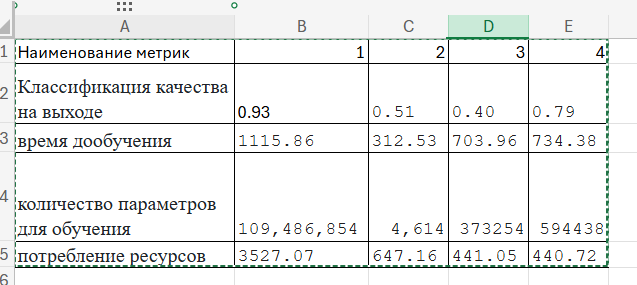